# **Progetto di BigData: Analisi di Wikipedia**

In [35]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql import DataFrame

from pyspark.ml.feature import Tokenizer, CountVectorizer, HashingTF, IDF, StopWordsRemover, StringIndexer, StandardScaler
from pyspark.ml import PipelineModel
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
#from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import math

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [3]:
URL_DATASET = "https://proai-datasets.s3.eu-west-3.amazonaws.com/wikipedia.csv"
!wget "{URL_DATASET}" -O wikipedia.csv

--2026-01-29 14:14:57--  https://proai-datasets.s3.eu-west-3.amazonaws.com/wikipedia.csv
Resolving proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)... 3.5.204.5, 3.5.204.27
Connecting to proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)|3.5.204.5|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1003477941 (957M) [text/csv]
Saving to: ‘wikipedia.csv’

wikipedia.csv       100%[===================>] 956.99M  32.8MB/s    in 30s     

2026-01-29 14:15:27 (32.1 MB/s) - ‘wikipedia.csv’ saved [1003477941/1003477941]



In [4]:
wikimedia_df = spark.read.csv("wikipedia.csv",
    header=True,
    multiLine=True,    #Permette di gestire in modo ottimale i \n
    quote='"',         #Permette di gestire i campi che iniziano e finiscono con "
    escape='"',        #Permette di gestisce i "" interni
    inferSchema=True
)

#Inseriamo i dati in ram per velocizzare l'elaborazione
wikimedia_df.cache()

DataFrame[_c0: int, title: string, summary: string, documents: string, categoria: string]

In [5]:
wikimedia_df.printSchema()
wikimedia_df.limit(10).toPandas()

root
 |-- _c0: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- summary: string (nullable = true)
 |-- documents: string (nullable = true)
 |-- categoria: string (nullable = true)



,_c0,title,summary,documents,categoria
0,0,economics,economics () is a social science that studies ...,economics () is a social science that studies ...,economics
1,1,index of economics articles,this aims to be a complete article list of eco...,this aims to be a complete article list of eco...,economics
2,2,cryptoeconomics,cryptoeconomics is an evolving economic paradi...,cryptoeconomics is an evolving economic paradi...,economics
3,3,economic impact analysis,an economic impact analysis (eia) examines the...,an economic impact analysis (eia) examines the...,economics
4,4,economic trend,economic trend may refer to: all the economic ...,economic trend may refer to: all the economic ...,economics
5,5,entrepreneurship,entrepreneurship is the creation or extraction...,entrepreneurship is the creation or extraction...,economics
6,6,factor investing,factor investing is an investment approach tha...,factor investing is an investment approach tha...,economics
7,7,filtering,"in housing economics, filtering is the process...","in housing economics, filtering is the process...",economics
8,8,free trade,free trade is a trade policy that does not res...,free trade is a trade policy that does not res...,economics
9,9,liquidation,liquidation is the process in accounting by wh...,liquidation is the process in accounting by wh...,economics


Modifichiamo i nomi delle colonne per rendere tutto più omogeneo

In [6]:
wikimedia_df = wikimedia_df.withColumnRenamed("_c0", "id")
wikimedia_df = wikimedia_df.withColumnRenamed("categoria", "category")
wikimedia_df.limit(10).toPandas()

,id,title,summary,documents,category
0,0,economics,economics () is a social science that studies ...,economics () is a social science that studies ...,economics
1,1,index of economics articles,this aims to be a complete article list of eco...,this aims to be a complete article list of eco...,economics
2,2,cryptoeconomics,cryptoeconomics is an evolving economic paradi...,cryptoeconomics is an evolving economic paradi...,economics
3,3,economic impact analysis,an economic impact analysis (eia) examines the...,an economic impact analysis (eia) examines the...,economics
4,4,economic trend,economic trend may refer to: all the economic ...,economic trend may refer to: all the economic ...,economics
5,5,entrepreneurship,entrepreneurship is the creation or extraction...,entrepreneurship is the creation or extraction...,economics
6,6,factor investing,factor investing is an investment approach tha...,factor investing is an investment approach tha...,economics
7,7,filtering,"in housing economics, filtering is the process...","in housing economics, filtering is the process...",economics
8,8,free trade,free trade is a trade policy that does not res...,free trade is a trade policy that does not res...,economics
9,9,liquidation,liquidation is the process in accounting by wh...,liquidation is the process in accounting by wh...,economics


## Analisi Esplorativa dei dati (EDA)

Andiamo a effettuare un'analisi descrittiva dei contenuti del dataset e nello specifico andremo a vedere:

**1. Conteggio degli articoli presenti per ogni categoria**

**2. Numero medio di parole per articolo**

**3. La lunghezza dell'articolo più lungo e di quello più corto per ciascuna categoria**

**4. Nuvole di parole rappresentative per ogni categoria, per identificare i termini più frequenti e rilevanti (In questa casistica selezioniamo le 10 parole più rappresentative di ogni categoria.)**

Per prima cosa andiamo a importare tutte le funzioni che ci serviranno per effettuare l'analisi.

In [7]:
def total_articles(df: DataFrame) -> int:
    """
    Conta il numero di articoli presenti nel DataFrame.

    Parameters:
    -----------
    df : pyspark.sql.dataframe.DataFrame
        Il DataFrame Spark di input.
    """
    return df.count()

In [8]:
def count_articles_by_category(df: DataFrame, category_col: str) -> DataFrame:
    """
    Conta il numero di articoli per ciascuna categoria.

    Parameters:
    -----------
    df : pyspark.sql.dataframe.DataFrame
        Il DataFrame Spark di input.

    category_col : str
        Il nome della colonna che contiene le categorie
    """
    #raggruppiamo per categoria ed effettuiamo i conteggi
    category_articles = df.groupBy(category_col).count().orderBy("count", ascending=False)

    #costruiamo il vocabolario
    category_articles_dict = {
        row[category_col]: row["count"] for row in category_articles.collect()
    }
    return category_articles_dict

In [9]:
def sum_columns(df: DataFrame, col_1: str, col_2: str, alias_name: str) -> DataFrame:
    """
    Somma le colonne specificate e aggiunge il risultato come nuova colonna.

    Parameters:
    -----------
    df : pyspark.sql.dataframe.DataFrame
        Il DataFrame Spark di input.

    col_1 , col_2 : str
        I nomi delle colonne da processare.

    alias_name : str
        Il nome della nuova colonna che conterrà il risultato della somma.
    """
    #sommiamo il numero di parole presenti in col_1 e in col_2
    total_words = df.withColumn(
        alias_name,
        F.size(F.split(F.col(col_1), " ")) + F.size(F.split(F.col(col_2), " "))
    )
    return total_words

In [10]:
def avg_column(df: DataFrame, col: str) -> int:
    """
    Ritorna la media della colonna specificata.

    Parameters:
    -----------
    df : pyspark.sql.dataframe.DataFrame
        Il DataFrame Spark di input.

    col : str
        Il nome della colonna da processare.
    """
    #controlliamo se la colonna contiene numeri o meno
    if not df.select(col).filter(F.col(col).rlike("^[0-9]*$")).count():
        raise ValueError(f"La colonna {col} non contiene numeri.")

    #calcoliamo la media della colonna specificata
    result = df.select(
        F.round(F.mean(col), 2).alias("avg")
    )
    avg = result.collect()[0][0]
    return avg

In [11]:
def get_max_min_len_dictionary(df: DataFrame, col_1: str, col_2: str, category_col: str, alias_name: str) -> dict:
    """
    Ritorna il numero di parole dell'articolo di lunghezza massima e dell'articolo di lunghezza minima
    per ciascuna categoria, sotto forma di dizionario.

    Parameters:
    -----------
    df : pyspark.sql.dataframe.DataFrame
        Il DataFrame Spark di input.

    col_1 , col_2 : str
        I nomi delle colonne che contengono i testi da processare.

    category_col : str
        Il nome della colonna che contiene le categorie

    alias_name : str
        Il nome della colonna che conterrà la lunghezza dei testi
    """

    #somma delle parole di col_1 e col_2
    result = sum_columns(df, col_1, col_2, alias_name)

    #raggruppamento per categoria e calcolo dell'articolo di massima e minima lunghezza
    stats_df = result.groupBy(category_col).agg(
        F.max(alias_name).alias("max_len"),
        F.min(alias_name).alias("min_len")
    )
    results_list = stats_df.collect()

    #costruzione del vocabolario delle lunghezze
    len_category = {
        row[category_col]: {
            "max_len": row["max_len"],
            "min_len": row["min_len"]
        } for row in results_list
    }

    return len_category

In [12]:
def get_top_words(df: DataFrame, text_col: str, category_col: str, top_n: int = 10) -> dict:
    """
    Permette di costruire un dizionario che rappresenta nuvole di parole rappresentative per ogni categoria.
    Il numero di parole più frequenti per ogni categoria sarà uguale a top_n

    Parameters:
    -----------
    df : pyspark.sql.dataframe.DataFrame
        Il DataFrame Spark di input.

    text_col : str
        Il nome della colonna che contiene il testo da processare

    category_col : str
        Il nome della colonna che contiene le categorie

    top_n : int, opzionale
        Il numero massimo di parole da selezionare per ciascuna categoria.
    """

    #filtro valori nulli e rimozione punteggiatura
    cleaned_df = df.filter(
        F.col(category_col).isNotNull() &
        F.col(text_col).isNotNull()
    ).select(
        category_col,
        F.lower(F.regexp_replace(F.col(text_col), r"[^a-z\s]", " ")).alias("clean_text")
    )

    #Tokenizzazione con gestione dei separatori
    tokenized_df = cleaned_df.withColumn(
        "words_array",
        F.array_remove(F.split(F.col("clean_text"), r"\s+"), "")
    ).filter(F.size(F.col("words_array")) > 0)

    #Rimozione Stopwords
    default_stop = StopWordsRemover.loadDefaultStopWords("english")
    custom_stop = [
        "also", "one", "two", "three", "four", "five", "new", "first",
        "second", "used", "using", "use", "known", "later", "including",
        "references", "many", "series", "became", "made", "well", "called",
        "part", "years", "time", "since", "often", "number", "including",
        "time", "year", "later", "million", "total", "every", "voiced",
        "back", "take", "set", "may", "economic"
    ]
    #Creiamo una lista unica di stopwords togliendo gli eventuali doppioni
    total_stop = list(set(default_stop + custom_stop))

    #Rimuoviamo le stopwords
    remover = StopWordsRemover(inputCol="words_array", outputCol="filtered_words", stopWords=total_stop)
    filtered_df = remover.transform(tokenized_df)

    #Explode (una parola per riga) e conteggio frequenze
    word_counts = filtered_df.select(
        category_col,
        F.explode(F.col("filtered_words")).alias("word")
    ).filter(
        F.length(F.col("word")) > 2
    ).groupBy(
        category_col,
        "word"
    ).count()

    #Specifica della window per la Top N
    window_spec = Window.partitionBy(category_col).orderBy(F.desc("count"))

    top_words_df = word_counts.withColumn(
        "rank",
        F.row_number().over(window_spec)
    ).filter(
        F.col("rank") <= top_n
    ).drop("rank")

    #Conversione Top N in dizionario
    results_list = top_words_df.collect()

    #Costruzione del vocabolario delle top words
    final_dict = {}
    for row in results_list:
        cat = row[category_col]
        if cat not in final_dict:
            final_dict[cat] = []

        final_dict[cat].append({
            "word": row["word"],
            "count": row["count"]
        })

    return final_dict

Importiamo tutte le funzioni che ci servono per la visualizzazione

In [13]:
def show_stats_len(dict_data: dict) -> None:
    """
    Stampa le statistiche di lunghezza per ciascuna categoria.

    Parameters:
    -----------
    dict_data : dict
        Il dizionario contenente le statistiche di lunghezza per ciascuna categoria.
    """
    if not dict_data:
        print("Nessun dato disponibile.")
        return
    print(f"\n{' STATISTICHE LUNGHEZZA (CARATTERI) ':=^50}")
    print(f"{'CATEGORIA':<20} | {'MAX':>10} | {'MIN':>10}")

    for categoria, stats in dict_data.items():
        print(f"{categoria:<20} | {stats['max_len']:>10} | {stats['min_len']:>10}")
    print("="*50)

def show_top_words(dict_data: dict, top_n: int = 10) -> None:
    """
    Stampa le top_n parole più frequenti per ciascuna categoria.

    Parameters:
    -----------
    dict_data : dict
        Il dizionario contenente le parole più frequenti per ciascuna categoria.
    top_n : int, opzionale
        Il numero massimo di parole da visualizzare per ciascuna categoria.
    """
    if not dict_data:
        print("Nessun dato disponibile.")
        return
    print(f"\n{'='*80} TOP {top_n} PAROLE PER CATEGORIA {'='*80}")
    for categoria, lista_parole in dict_data.items():
        print(f"[{categoria:<12}] -> {', '.join([f'{item["word"]}({item["count"]})' for item in lista_parole])}")
    print("="*190)

def show_count_articles(dict_data: dict) -> None:
    """
    Stampa il numero di articoli per ciascuna categoria.

    Parameters:
    -----------
    dict_data : dict
        Il dizionario contenente il numero di articoli per ciascuna categoria
    """
    if not dict_data:
        print("Nessun dato disponibile.")
        return
    print(f"\nNUMERO DI ARTICOLI PER CATEGORIA")
    for categoria, count in dict_data.items():
        print(f"[{categoria:<12}] -> {count}")
    print("="*32)

In [34]:
def plot_category_distribution_from_dict(category_dict) -> None:
    """
    Riceve il dizionario generato dalla funzione count_articles_by_category
    e crea un grafico a barre.
    """
    print("Generazione grafico distribuzione...")

    #Convertiamo il dizionario in un DataFrame Pandas
    pdf = pd.DataFrame.from_dict(category_dict, orient='index', columns=['count'])

    #Resettiamo l'indice per avere la colonna 'category' utilizzabile da Seaborn
    pdf = pdf.reset_index().rename(columns={'index': 'category'})

    #Creazione del grafico
    plt.figure(figsize=(12, 6))
    sns.barplot(data=pdf, x="count", y="category", palette="viridis", hue="category", legend=False)

    #Aggiungiamo etichette di testo con i valori esatti alla fine di ogni barra
    for i, v in enumerate(pdf['count']):
        plt.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

    plt.title("Distribuzione degli Articoli per Categoria")
    plt.xlabel("Numero di Articoli")
    plt.ylabel("Categoria")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_stats_len_from_dict(len_category_dict) -> None:
    """
    Riceve il dizionario con max_len e min_len per categoria e crea un grafico a barre comparativo.
    Usa una scala logaritmica per rendere visibili i valori minimi molto piccoli.
    """
    print("Generazione grafico lunghezze (Max vs Min) con scala logaritmica...")

    #Trasformiamo il dizionario in una lista di record per Pandas
    data_list = []
    for category, stats in len_category_dict.items():
        #Usiamo max(len, 1) per evitare problemi con il logaritmo se il valore è 0
        data_list.append({
            'category': category,
            'type': 'Massima',
            'length': max(stats.get('max_len', 0), 1)
        })
        data_list.append({
            'category': category,
            'type': 'Minima',
            'length': max(stats.get('min_len', 0), 1)
        })

    pdf = pd.DataFrame(data_list)

    if pdf.empty:
        print("Il dizionario delle lunghezze è vuoto.")
        return

    #Creazione del grafico
    plt.figure(figsize=(14, 10))
    plot = sns.barplot(
        data=pdf,
        x="length",
        y="category",
        hue="type",
       #palette={"Massima": "#2ecc71", "Minima": "#e74c3c"}
        palette={"Massima": "#00ff00", "Minima": "#ff0000"}
    )

    #Impostiamo una scala logaritmica per visualizzare meglio anche i valori piccoli
    plt.xscale('log')

    #Aggiunta delle etichette numeriche reali per chiarezza
    #Analizzando per singolo rettangolo
    for p in plot.patches:
        width = p.get_width()
        if width > 0:
            #Calcoliamo una piccola distanza basata sulla scala logaritmica (aggiungiamo il 10% alla width)
            plt.text(width * 1.1, p.get_y() + p.get_height()/2,
                     f'{int(width)}',
                     va='center', fontsize=9, fontweight='bold')

    plt.title("Confronto Lunghezze Articoli per Categoria", fontsize=15)
    plt.xlabel("Numero di Parole", fontsize=12)
    plt.ylabel("Categoria", fontsize=12)
    plt.legend(title="Legenda", loc='lower right')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_word_clouds_from_dict(top_words_dict, categories_to_show=None, cols=4) -> None:
    """
    Genera una griglia di Word Clouds (Top parole).

    Parameters:
    -----------
    top_words_dict : dict
        Dizionario { categoria: [{'word': w, 'count': n}, ...] }
    categories_to_show : list, opzionale
        Lista delle categorie da mostrare nella griglia
    cols : int
        Numero di colonne (default 4).
    """

    cats = categories_to_show if categories_to_show else list(top_words_dict.keys())
    n_cats = len(cats)

    if n_cats == 0:
        return

    #Definiamo il numero di righe di cloud words
    rows = math.ceil(n_cats / cols) #arrotondamento per eccesso

    plt.figure(figsize=(18, 3 * rows))

    for i, cat in enumerate(cats):
        if cat not in top_words_dict:
            continue

        word_freqs = {item['word']: item['count'] for item in top_words_dict[cat]}

        if not word_freqs:
            continue

        #Costruzione delle word clouds
        wordcloud = WordCloud(
            width=350,
            height=200,
            background_color='white',
            colormap='tab10',
            max_font_size=45,
            min_font_size=10,
            prefer_horizontal=0.7, #Più parole orizzontali per risparmiare spazio
            relative_scaling=0.5
        ).generate_from_frequencies(word_freqs)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f"{cat.upper()}", fontsize=11, fontweight='bold', color='#000000')
        plt.axis('off')

    plt.tight_layout(pad=2.0)
    plt.show()

Iniziamo col vedere il numero totale di articoli presenti nel dataset.

In [15]:
num_articles = total_articles(wikimedia_df)
print(f"Il dataset contiene {num_articles} articoli.\n")

Il dataset contiene 153232 articoli.



1. Conteggio degli articoli presenti per ogni categoria.


NUMERO DI ARTICOLI PER CATEGORIA
[politics    ] -> 11358
[culture     ] -> 10372
[science     ] -> 10236
[humanities  ] -> 10236
[engineering ] -> 10220
[finance     ] -> 10157
[transport   ] -> 10130
[economics   ] -> 10110
[technology  ] -> 10095
[medicine    ] -> 10076
[trade       ] -> 10068
[sports      ] -> 10068
[energy      ] -> 10046
[research    ] -> 10037
[pets        ] -> 10023


Generazione grafico distribuzione...


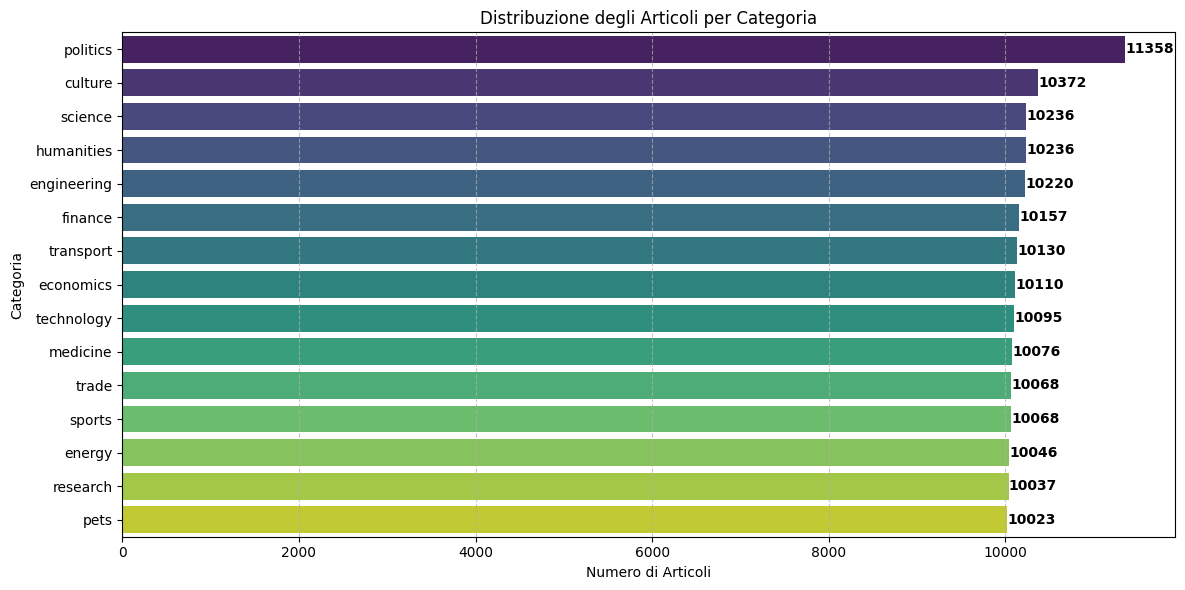

In [16]:
count_category_articles = count_articles_by_category(wikimedia_df, "category")
show_count_articles(count_category_articles)
print("\n")
plot_category_distribution_from_dict(count_category_articles)

2. Numero medio di parole per articolo.

In [17]:
mean_articles = avg_column(sum_columns(wikimedia_df, "summary", "documents", "total_words"), "total_words")
print(f"Il numero medio di parole per articolo è {mean_articles}\n")

Il numero medio di parole per articolo è 1039.63



3. La lunghezza dell'articolo più lungo e di quello più corto per ciascuna categoria.


======= STATISTICHE LUNGHEZZA (CARATTERI) ========
CATEGORIA            |        MAX |        MIN
finance              |      33497 |          6
medicine             |      18882 |         22
research             |      27333 |         32
technology           |      18426 |          4
energy               |      23776 |         18
transport            |      22471 |         14
politics             |      20174 |         16
culture              |      16112 |         20
science              |      29441 |         28
humanities           |      23278 |         14
economics            |      24621 |         18
trade                |      20275 |         30
sports               |      19871 |         20
pets                 |      13409 |         22
engineering          |      12416 |         16


Generazione grafico lunghezze (Max vs Min) con scala logaritmica...


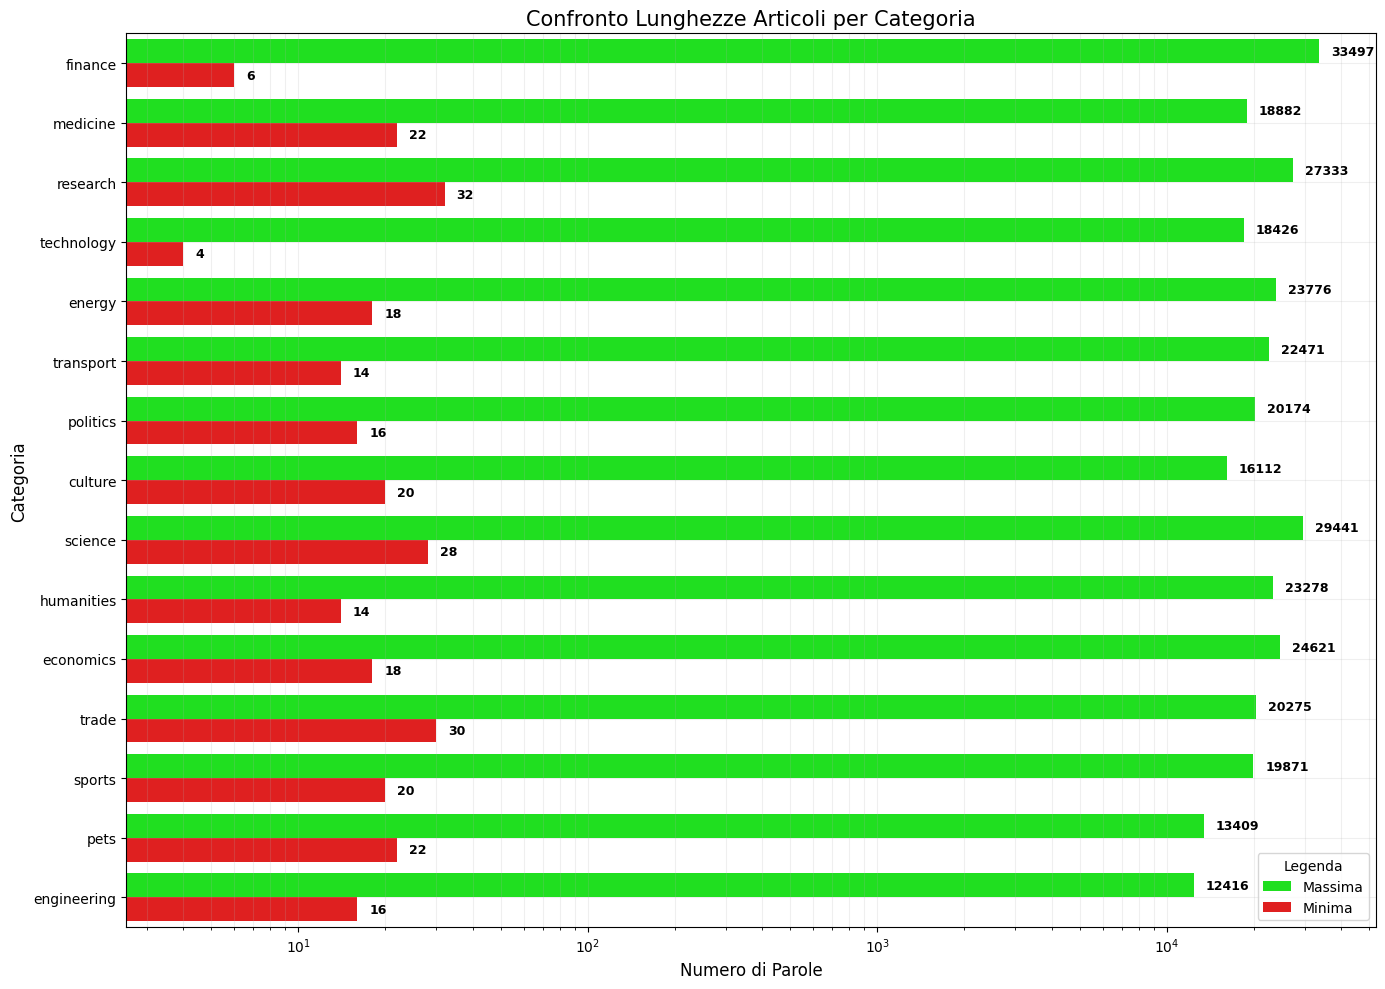

In [32]:
len_category = get_max_min_len_dictionary(wikimedia_df, "summary", "documents", "category", "total_words")
show_stats_len(len_category)
print("\n")
plot_stats_len_from_dict(len_category)

4. Nuvole di parole rappresentative per ogni categoria, per identificare i termini più frequenti e rilevanti (Selezioniamo le 10 parole più rappresentative di ogni categoria.)

In [19]:
top_words_dict = get_top_words(wikimedia_df, "documents", "category", 10)
show_top_words(top_words_dict, 10)


================================================================================ TOP 10 PAROLE PER CATEGORIA ================================================================================
[culture     ] -> film(41597), meitei(34080), language(25229), manipur(20903), khamba(16589), manipuri(15370), dance(14770), india(13416), indian(13082), festival(10845)
[economics   ] -> party(53654), university(33255), socialist(32716), international(23210), workers(21537), labour(18417), economics(17153), group(17098), left(16536), political(16202)
[energy      ] -> power(85364), station(38405), plant(34705), energy(32007), company(29877), electricity(26337), gas(19266), coal(16843), electric(16100), capacity(14695)
[engineering ] -> river(21480), water(21396), dresden(14973), german(11412), bridge(10579), engineering(9896), company(9729), air(9283), world(8110), built(7625)
[finance     ] -> man(75095), company(55381), universe(41939), masters(41342), king(30475), skeletor(29744), cartoon(29469

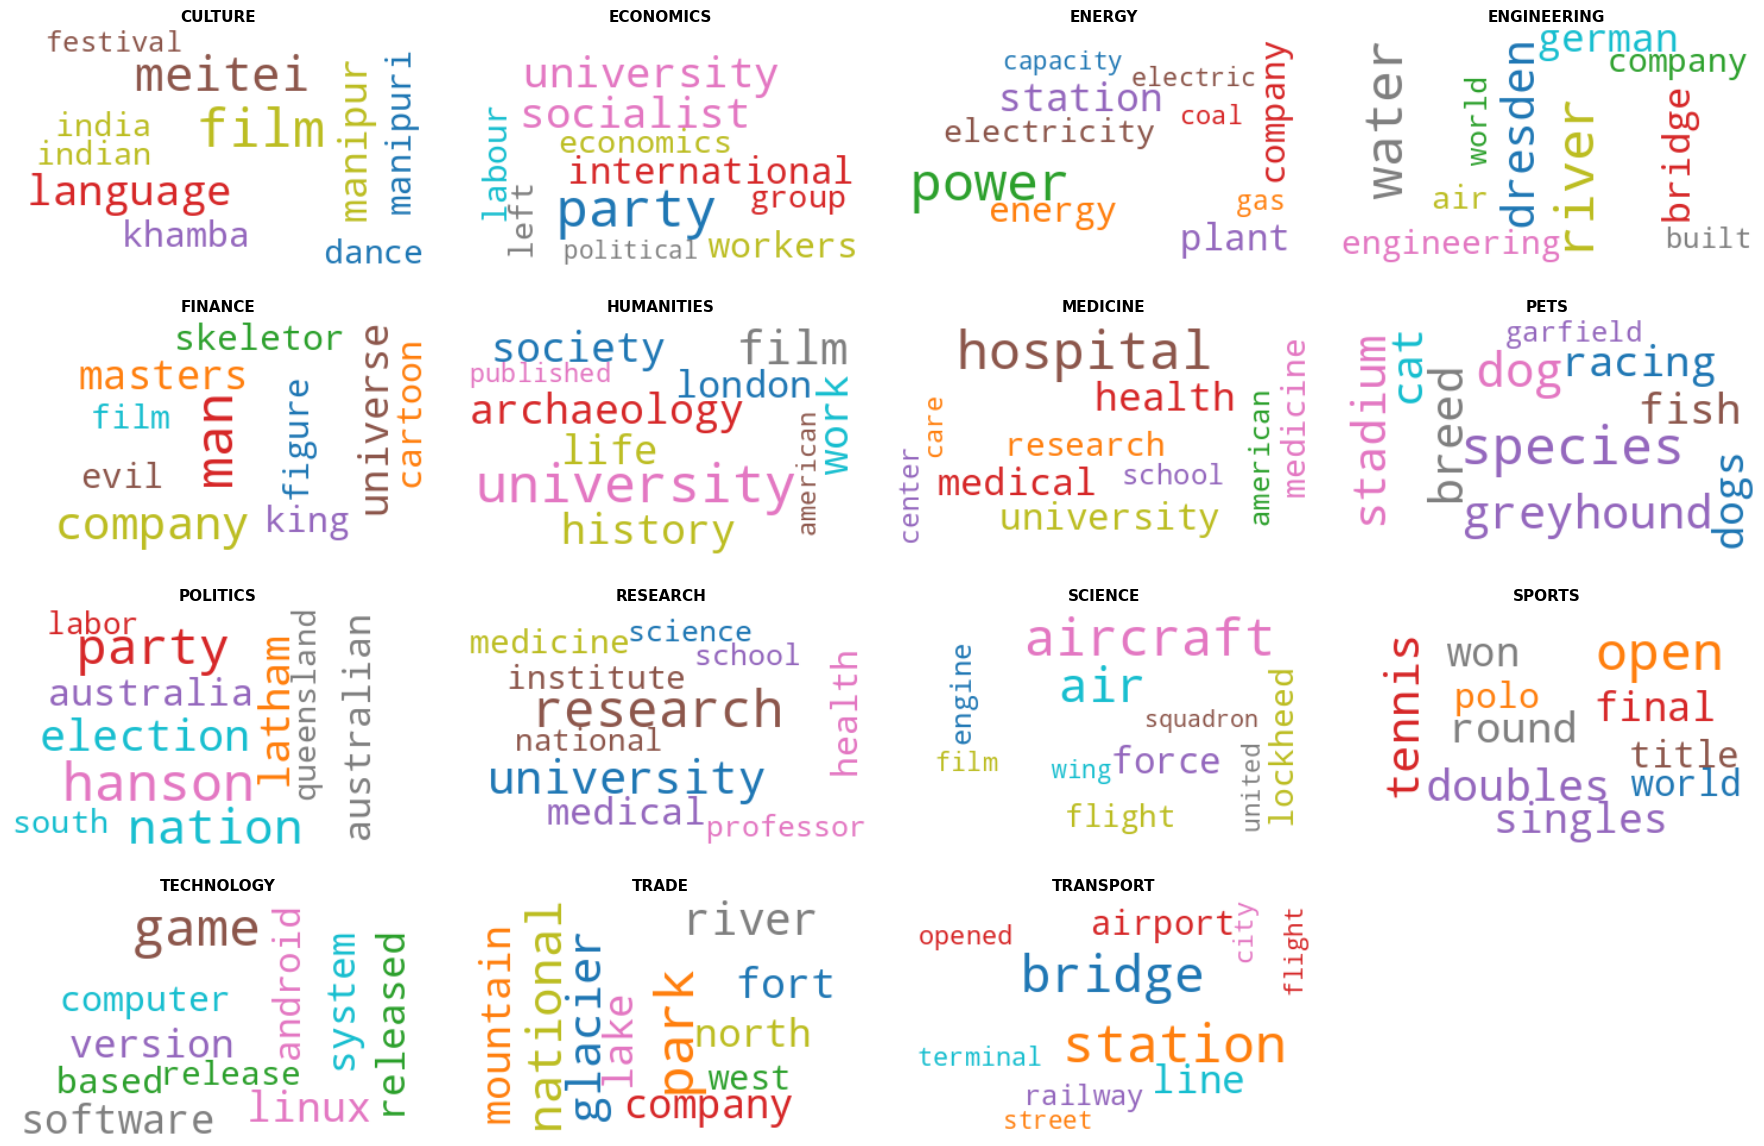

In [33]:
plot_word_clouds_from_dict(top_words_dict)

## Sviluppo di un Classificatore Automatico

L'obiettivo è creare un modello di machine learning capace di classificare automaticamente gli articoli in base alla loro categoria. Il sistema di classificazione verrà addestrato utilizzando dati di testo presenti nelle seguenti colonne del dataset:
- Sommario (summary): Introduzione breve dell'articolo.
- Testo Completo (documents): Contenuto completo dell'articolo.

In [21]:
def build_classification_model(df: DataFrame, inputCol) -> PipelineModel:
    """
    Costruisce una pipeline con Text Processing, Scaling e Logistic Regression
    partendo da un df contenente le colonne text_combined e label, dove
    text_combined è la concatenazione di summary e documents e label è il target indicizzato.

    Parameters:
    -----------
    df : pyspark.sql.dataframe.DataFrame
        Il DataFrame Spark di input.
    inputCol : str
        Il nome della colonna che contiene il testo da processare per l'estrazione delle feature.
        In questo caso sarà la colonna che si riferisce alla concatenazione di summary e documents.

    Returns:
    --------
    pyspark.ml.pipeline.PipelineModel
        Il modello della pipeline addestrato pronto per essere utilizzato per trasformazioni o predizioni.

    """
    print("Pulizia della cache Spark per liberare memoria...")
    df.sparkSession.catalog.clearCache()

    tokenizer = Tokenizer(inputCol=inputCol, outputCol="words")
    remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
    vectorizer = CountVectorizer(inputCol="filtered_words", outputCol="raw_features", vocabSize=10000, minDF=10.0)
    scaler = StandardScaler(inputCol="raw_features", outputCol="scaled_features", withStd=True, withMean=False)
    lr = LogisticRegression(featuresCol="scaled_features", labelCol="label", maxIter=20, regParam=0.05)

    pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, scaler, lr])

    train_data, test_data = df.randomSplit([0.8, 0.2], seed=0)

    #caching del dataset di train per velocizzare il processo di addestramento
    train_data.cache()

    try:
        print("Training della pipeline...")
        model = pipeline.fit(train_data)
        print("Training completato con successo.")
        return model
    except Exception as e:
        print(f"Errore durante il training: {e}")
        return None
    finally:
        train_data.unpersist()

In [22]:
def plot_classification_report(predictions, class_names) -> None:
    """
    Genera una heatmap del report di classificazione (Precision, Recall, F1).
    """
    y_true = predictions.select("label").collect()
    y_pred = predictions.select("prediction").collect()
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).T
    report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
    report_df = report_df.drop(columns=['support'], errors='ignore')

    plt.figure(figsize=(10, 8))
    sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt=".2f", cbar=False)
    plt.title('Performance per Categoria (Precision, Recall, F1)', fontsize=14, pad=20)
    plt.xlabel('Metriche')
    plt.ylabel('Categorie')
    plt.tight_layout()
    plt.show()

In [23]:
df_combined = wikimedia_df.withColumn("text_combined", F.concat_ws(" ", F.col("summary"), F.col("documents")))

label_indexer = StringIndexer(inputCol="category", outputCol="label", handleInvalid="skip")
label_model = label_indexer.fit(df_combined)

df_combined = label_model.transform(df_combined)
class_names = label_model.labels

In [24]:
model = build_classification_model(df_combined, "text_combined")

Pulizia della cache Spark per liberare memoria...
Training della pipeline...
Training completato con successo.


In [25]:
train_data, test_data = df_combined.randomSplit([0.8, 0.2], seed=0)

In [26]:
train_pred = model.transform(train_data)
test_pred = model.transform(test_data)

In [27]:
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
train_accuracy = evaluator.evaluate(train_pred)
test_accuracy = evaluator.evaluate(test_pred)

In [28]:
print(f"L'accuracy sul dataset di train è:{(train_accuracy*100):.2f}%")
print(f"L'accuracy sul dataset di test è:{(test_accuracy*100):.2f}%")

L'accuracy sul dataset di train è:94.40%
L'accuracy sul dataset di test è:91.88%


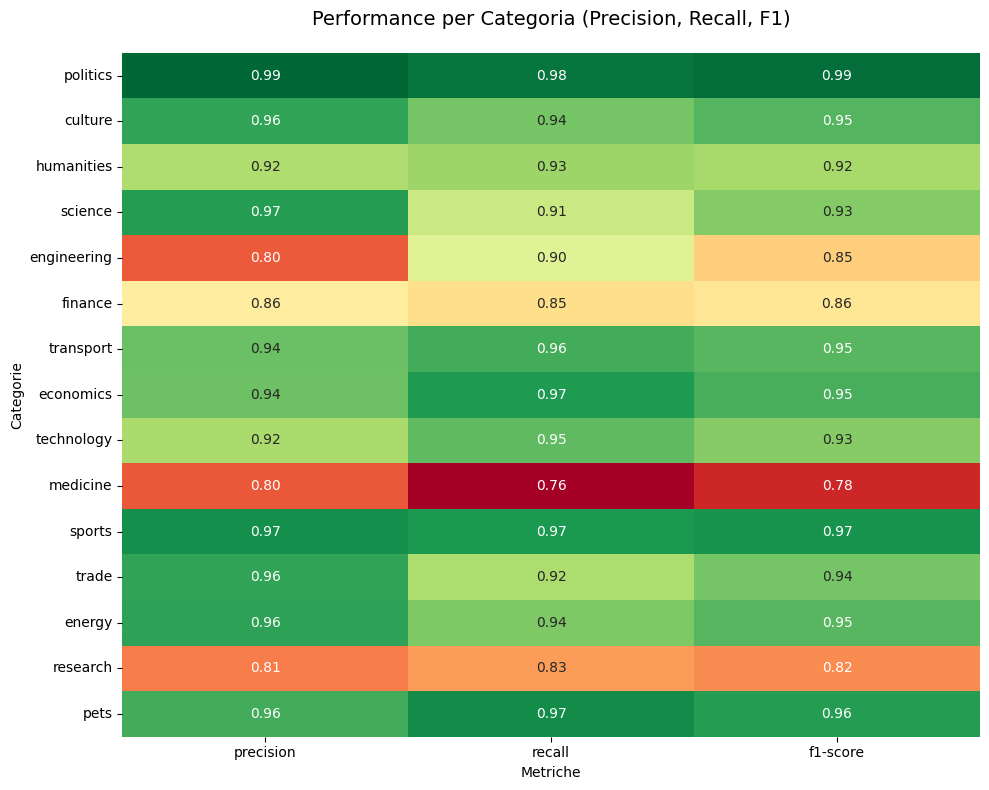

In [29]:
plot_classification_report(test_pred, class_names)

---

## **Analisi Strategica e Classificazione Automatica dei Contenuti di Wikipedia**

### 1. Analisi Strategica dei Contenuti (EDA)

Sulla base dell'Analisi Esplorativa (EDA) sono stati identificati i seguenti insights chiave per supportare gli sforzi editoriali di Wikimedia.

L'analisi è stata condotta su un campione di 153.232 articoli distribuiti in 15 categorie tematiche principali. L'obiettivo è mappare lo stato attuale della copertura informativa e identificare aree di miglioramento per la qualità dell'enciclopedia.

**Analisi della Copertura e Distribuzione**

Il dataset si mostra molto equilibrato, circa 10.000 articoli per categoria, poco più per la categoria "politics" (circa 11.000). Questo indica uno sforzo editoriale ben bilanciato tra i vari rami del sapere.

Questo è sicuramente un punto di forza in quanto la parità numerica tra categorie garantisce che l'utente trovi una base di partenza solida in ogni disciplina.

**Profondità dei Contenuti**

La lunghezza media di 1039 parole per articolo è un indicatore di alta qualità editoriale, in quanto dice implicitamente che Wikipedia non è solo un dizionario, ma un archivio di approfondimento. Gli articoli sono mediamente lunghi a sufficienza per fornire un contesto esaustivo.
D'altro canto una criticità è sicuramente la presenza di articoli estremamente brevi (es. 4-6 caratteri), che evidenzia la necessità di una migliore gestione di questi, per esempio definendo una soglia minima di caratteri, in modo tale da evitare pagine di scarsa utilità informativa.

**Identificazione Bias di Contenuto**

L'analisi delle parole chiave rivela che alcune categorie non sono generiche, ma si focalizzano su specifiche bolle di conoscenza.

Per esempio vi è un bias geografico per la categoria "politics" che è fortemente dominata dalla politica australiana, nella categoria "engineering" principalmente legata alla Germania, oppure nella categoria "culture" con l'India.
Una raccomandazione per Wikimedia, quindi, è sicuramente quella di incentivare i contributi per altre aree geografiche.

La categoria scientifica è quasi interamente incentrata sull'aviazione e l'aeronautica.
Sarebbe meglio quindi riempire con contenuti di scienze fondamentali come Biologia, Chimica, Fisica, ecc.

Vi è, inoltre, una contaminazione commerciale nella categoria "finance": in "finance", la prevalenza di termini è legata a franchise commerciali o collezionismo.
Una raccomandazione potrebbe essere di rafforzare la distinzione editoriale tra "Finanza Economica" e "Finanza relativa a valore di mercato di Brand/Media".

**Analisi dei Cluster Tematici di Successo**

Alcune categorie mostrano una struttura perfetta e professionale:

"medicine" e "research" sono categorie focalizzate su università, ospedali e ricerca clinica. Questo riflette un'alta affidabilità e una cura rigorosa di questi temi sensibili.

"technology" mostra una forte adozione della cultura Open Source (Linux, Android, Software), perfettamente in linea con la linea editoriale di Wikimedia.

### 2. Analisi delle Performance del Classificatore

**Scelte Tecniche e Risultati Globali**

Come classificatore è stato scelto un modello di regressione logistica. Non è stato scelto un modello più avanzato per motivi di mancanza di potenza di calcolo, in quanto su Google Colab stiamo semplicemente "simulando" un ambiente Spark.

Nonostante ciò in questa casistica il modello LogisticRegression è comunque una buona scelta, infatti otteniamo performance abbastanza alte, con 92% di accuracy sul dataset di test. Analizzando meglio le performance con l'heatmap che mostra metriche come Precision, Recall e F1, notiamo che le performance potrebbero essere anche molto più alte, ma il modello fa fatica a classificare bene le categorie "medicine" e "research". Anche se i termini sono molto pertinenti per le due categorie, sono tra loro molto simili; questo probabilmente porta a un calo delle performance.
Un calo che si riscontra anche per la categoria "finance", probabilmente dovuto alla contaminazione con la finanza relativa a Brand/Media.

### 3. Conclusioni e Raccomandazioni Strategiche

In sintesi, l'analisi dimostra che Wikipedia è una risorsa robusta, ma con "isole di specializzazione" molto marcate. Per migliorare sia l'enciclopedia che la precisione dei futuri modelli di classificazione, si raccomanda di:

- bilanciare i contenuti interni alle categorie (es. più scienze di base, meno aviazione)

- incentivare i contributi per aree geografiche sottorappresentate

- implementare una soglia minima di caratteri per gli articoli

- rafforzare la distinzione editoriale tra domini simili come Ricerca e Medicina.